In [1]:
%matplotlib inline
# %matplotlib notebook

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Visualization of operators

Today, lets visulize some unary and binary fuzzy set operators

**Complement Operators**

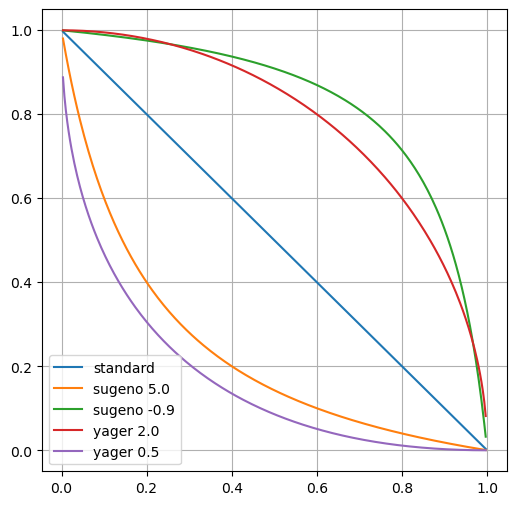

In [2]:
N = 300

x = np.asarray( range(1,N,1) ) / N
y = np.zeros( x.size )

fig = plt.figure(figsize=(6, 6))
ax = plt.axes()

# Standard complement:
standard = 1.0 - x
ax.plot(x,standard,label='standard')

#Sugeno complement:  C(x) = (1-x)/(1 + lamda*x)

sugeno_l = 5.0 # lamda   5 is more "aggresive", drop fast
sugeno = ( 1.0 - x ) / ( 1 + sugeno_l * x )
ax.plot(x,sugeno,label='sugeno 5.0')

sugeno_l = -0.9
sugeno = ( 1.0 - x ) / ( 1 + sugeno_l * x )
ax.plot(x,sugeno,label='sugeno -0.9')  # softer, drop slowly

yager_w = 2.0
yager = (1 - x ** yager_w) ** (1.0 / yager_w)
ax.plot(x,yager,label='yager 2.0')

yager_w = 0.5
yager = (1 - x ** yager_w) ** (1.0 / yager_w)
ax.plot(x,yager,label='yager 0.5')

ax.legend()
plt.grid()
plt.show()

**t-norm operators**

**Short answer:**

A **t-norm (triangular norm)** is a mathematical function used in fuzzy logic to represent the **AND** operation.

It takes two inputs (a, b \in [0,1]) and outputs a value in ([0,1]), satisfying:

* **Commutative:** (T(a,b) = T(b,a))
* **Associative:** (T(a, T(b,c)) = T(T(a,b), c))
* **Monotonic:** If (a \le a') then (T(a,b) \le T(a',b))
* **1 is identity:** (T(a,1) = a)

Examples:

* Product t-norm: (T(a,b) = a \cdot b)
* Minimum t-norm: (T(a,b) = \min(a,b))

Used to model fuzzy "AND".


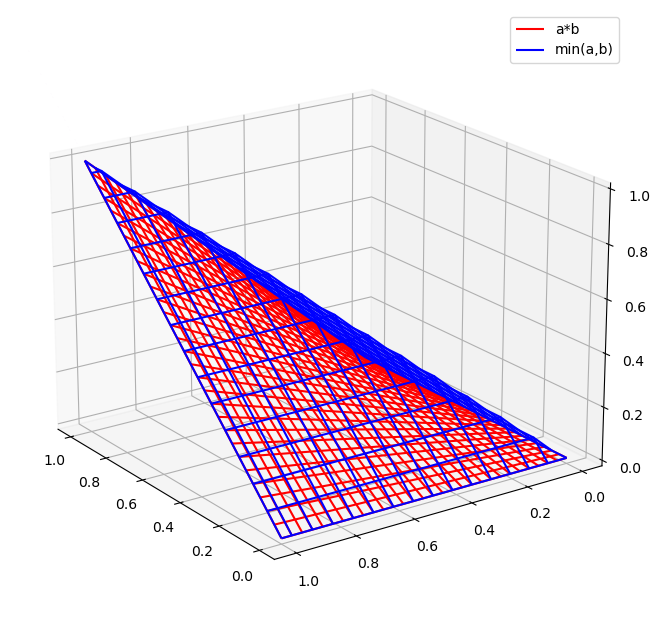

In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection='3d')
N = 30
x = np.outer(np.linspace(0, 1, N), np.ones(N))
y = x.copy().T

# operator 1
z = np.multiply(x,y)
ax.plot_wireframe(x, y, z, rstride=1, cstride=1, color='r', label='a*b')

# operator 2
z = np.minimum(x,y)
ax.view_init(elev=20, azim=145)
ax.plot_wireframe(x, y, z, rstride=2, cstride=2, color='b', label='min(a,b)')

ax.legend()
plt.draw()

**t-conorm operators**

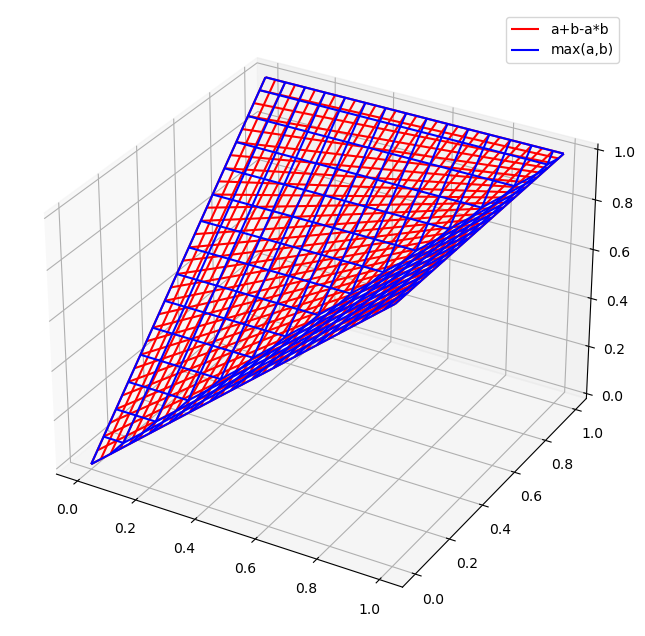

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection='3d')
N = 30
x = np.outer(np.linspace(0, 1, N), np.ones(N))
y = x.copy().T

# operator 1
z = x + y - np.multiply(x,y)
ax.plot_wireframe(x, y, z, rstride=1, cstride=1, color='r', label='a+b-a*b')

# operator 2
z = np.maximum(x,y)
ax.plot_wireframe(x, y, z, rstride=2, cstride=2, color='b', label='max(a,b)')

ax.legend()
plt.draw()

Here is another cool python lib that you can use to viz the above

Note, you can extend it to more points/samples if you like/need

[[0 0]
 [1 0]
 [0 1]
 [1 1]]
[[0, 1, 2], [1, 2, 3]]


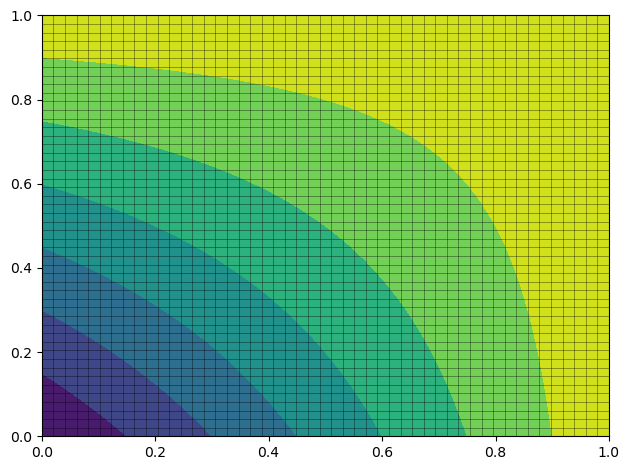

In [16]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np

xy = [ [0,0], [1,0], [0,1], [1,1] ]
xy = np.array(xy)
triangles = [ [0, 1, 2], [1, 2, 3] ]
triang = mtri.Triangulation(xy[:,0], xy[:,1], triangles=triangles)
print(xy)
print(triangles)
    
#z = np.maximum(xy[:,0],xy[:,1])
z = xy[:,0] + xy[:,1] - np.multiply(xy[:,0],xy[:,1])

xi, yi = np.meshgrid(np.linspace(0,1,50), np.linspace(0, 1, 50))

interp_cubic_geom = mtri.CubicTriInterpolator(triang, z, kind='min_E')
zi_cubic_geom = interp_cubic_geom(xi, yi)

plt.figure()
plt.contourf(xi, yi, zi_cubic_geom)
plt.plot(xi, yi, 'k-', lw=0.5, alpha=0.5)
plt.plot(xi.T, yi.T, 'k-', lw=0.5, alpha=0.5)

plt.tight_layout()
plt.show()